In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
import pandas as pd
import statistics
from array import array
import glob
import re

In [ ]:
# pass the txt file directly as it is produced by the parameter analyzer and produce two lists with time and current

current = [] # A  --> assumes charge MPV is already corrected for temperature variations
time = [] # s

start_line = 117  #Depending on the device analyzer, choose the value accordingly. And do not mix files from different device analyzers!
txt = "/Users/icosivi/Desktop/W12_1-6_CurrentStability/pippo.txt"

with open(txt,"r") as t:
        lines_list = t.readlines()
        lineo = lines_list[0]
        header_line = re.split(" |\t",lineo)
        header = re.split('_|-|\n',header_line[2])
        #print(header)
        lines = lines_list[start_line:]

        for k, line in enumerate(lines):
            if float(line.split("	")[0])<0:
                if( len(time)>3 ):
                    if( -1*float(line.split("	")[0])>-1*float(lines[k-1].split("	")[0]) ):
                        time.append( -1*float(line.split("	")[0]) )
                    else:
                        break
                else:
                    time.append( -1*float(line.split("	")[0]) )
            else:
                if( len(time)>3 ):
                    if( float(line.split("	")[0])>float(lines[k-1].split("	")[0]) ):
                        time.append( float(line.split("	")[0]) )
                    else:
                        break
                else:
                    time.append( float(line.split("	")[0]) )

            if float(line.split("	")[1])<0:
                current.append( -1*float(line.split("	")[1]) )
            else:
                current.append( float(line.split("	")[1]) )
                

In [11]:
wafer = 12 #
row = 3 #
column = 3 # 
irradiation = 0 # expressed in n_{eq}/cm^{2}
temperature = -25

#stability = ((max(current)-min(current))/statistics.mean(current))*100
stability = ((statistics.stdev(current))/statistics.mean(current))*100
print("Current stability: "+str(stability)+" %")

tests_json = []

dtz = datetime(2026, 2, 25, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

save_path = '/Users/icosivi/Desktop/LFoundry/plot_UFSDLF_LC2/'
xl_filename="UFSDLF2_16x16_ETLdb"
wb = pd.read_excel(save_path+xl_filename+'.xlsx')

v_serialn = str(wb[(wb['Wafer'] == wafer) & (wb['Row'] == row) & (wb['Column'] == column)]['SerialNumber'].iloc[0])

vendor = "FBK"
production = "UFSD-LF"
user = "fsiviero" # cern user of who's uploading the test
location = "Torino" # where the test was performed
json_filename="ETL_site_current-stability"


pippo = {'component': v_serialn,
        'name': 'Sensor Current Stability',
        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
        'location': location,
        'user_created': user,
        'version': 'v0',
        'irradiation_level': irradiation,
        'measuring_temperature': temperature,
        'current_stability': stability,
        'current': current,
        'time': time
        }
               
tests_json.append(pippo)


with open(save_path+json_filename+".json", 'w') as f:
   json.dump(tests_json, f, indent=4) 

Current stability: 4.2996061918497395 %


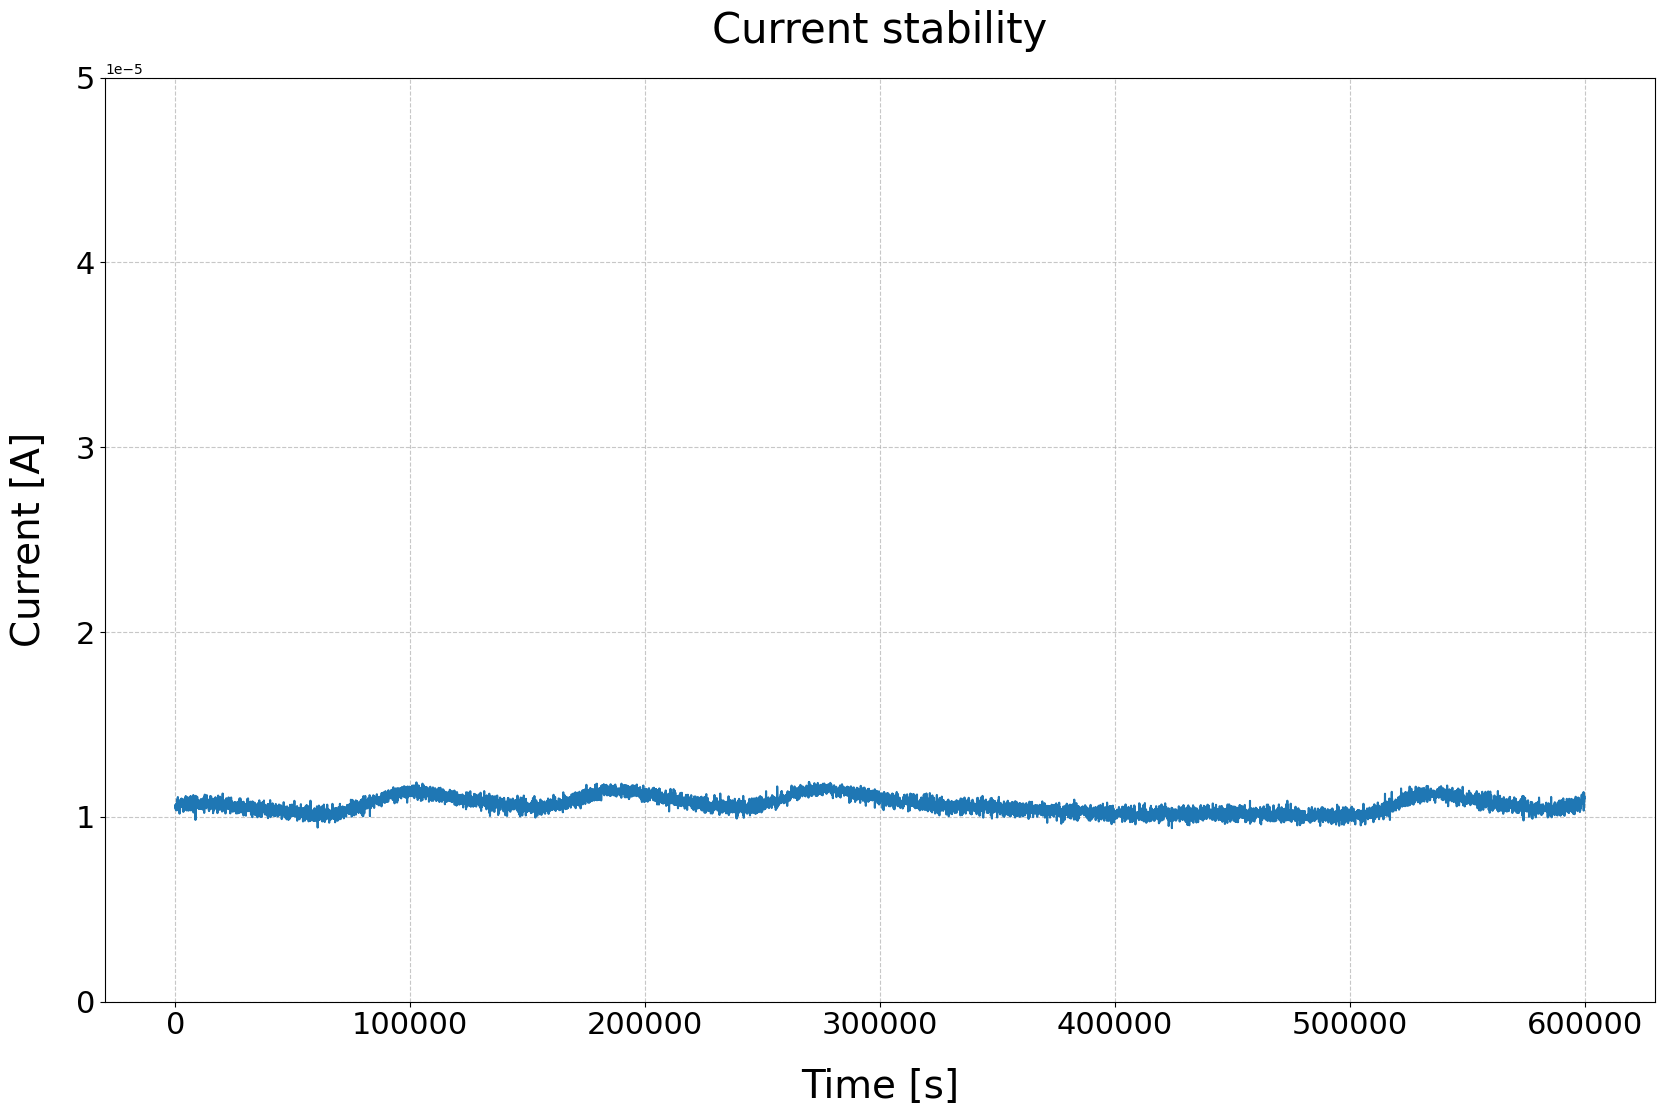

In [10]:
plt.figure(figsize=(20, 12))
plt.title("Current stability",fontsize=30,pad=25)

plt.plot(time,current)

plt.xlabel("Time [s]",fontsize=28,labelpad=20)
plt.ylabel("Current [A]",fontsize=28,labelpad=20)
#plt.xlim(0, 160) # set the limit of the x axis to 0-9
plt.ylim(0, 50E-6) # set the limit of the y axis to 0-9

#y_ticks_major = np.arange(0, 51, 5) 
#plt.yticks(y_ticks_major)

plt.tick_params(axis='y', labelsize=22)
plt.tick_params(axis='x', labelsize=22)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)

#plt.savefig("/Users/icosivi/Desktop/1.png")
plt.show()